In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 1 — Imports + pipeline build (uses cached features if available)
# ═══════════════════════════════════════════════════════════════════════════════

import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.preprocessing import StandardScaler
import sklearn_crfsuite

from dutch_30_pipeline import Dutch30Pipeline
from dutch_30_feature_extractor import Dutch30FeatureExtractor
from dataset_config import Dutch30Config
from run_pipeline import DEFAULT_RUN_CONFIG, run_path_b

Running from clean repo, using data from: C:\mozg\code\SingleWordProductionDutch


In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2 — Build pipeline (uses defaults from your latest commit: pwr_lpf,
#            window=15ms, shift=5ms, stk=20)
# ═══════════════════════════════════════════════════════════════════════════════

config = Dutch30Config()
extractor = Dutch30FeatureExtractor(config=config)
pipeline = Dutch30Pipeline(
    dutch30_extractor=extractor,
    debug_mode=False,
    feature_extraction_method='high_gamma',
    use_wav2vec=False,
    subtract_baseline=False,
    use_rms_boundaries=False,
    use_multifeature=False,
)

run_config = dict(DEFAULT_RUN_CONFIG)
run_config['use_viterbi'] = True
# stacking_order=20, step_size=1 are now the new defaults; no override needed

print("Building pipeline (uses cached features if present)...")
run_path_b(pipeline, run_config)
print(f"  train phonemes: {len(pipeline.train['features'])}")
print(f"  test phonemes:  {len(pipeline.test['features'])}")

Dutch30FeatureExtractor: Dutch30FeatureExtractor initialized:
Dutch30FeatureExtractor:   Data dir: C:\mozg\code\SingleWordProductionDutch\Dutch_30patients\raw
Dutch30FeatureExtractor:   Results dir: C:\mozg\code\SingleWordProductionDutch\results\dutch30
Dutch30FeatureExtractor:   Sampling rate: 1024 Hz
CustomBrainAudioDecoder: Initializing CustomBrainAudioDecoder with debug_mode=False
PhoneticDictionary: Initialized with DEBUG_MODE=False
PhoneticDictionary: Found 728 sentence-level entries
PhoneticDictionary: Added 1997 individual word entries
PhoneticDictionary: Skipped 0 sentences with unresolvable mismatches
UnifiedPhonemePipeline: Pipeline initialized: high_gamma, PCA=100, groups=False
PhoneticDictionary: Initialized with DEBUG_MODE=False
PhoneticDictionary: Found 728 sentence-level entries
PhoneticDictionary: Added 1997 individual word entries
PhoneticDictionary: Skipped 0 sentences with unresolvable mismatches
UnifiedPhonemePipeline: Pipeline initialized: high_gamma, groups=False

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3 — Helper: run CRF with a chosen scaling strategy
# ═══════════════════════════════════════════════════════════════════════════════

def features_to_crf_dict(features):
    """Convert a feature vector (1D array) to a dict format for sklearn-crfsuite."""
    return {f'f{i}': float(v) for i, v in enumerate(features)}


def run_with_scaling(pipeline, scaling_kind):
    """Run CRF per patient using a specific scaling strategy.

    scaling_kind options:
      'standard'  — z-score (subtract mean, divide by std)
      'mean_only' — subtract mean only (no std division)
      'none'      — no scaling at all
    """
    print(f"\n  Running with scaling = '{scaling_kind}'")
    pids = sorted(set(pipeline.train['phoneme_participant_ids']))
    results = {}

    for pid in pids:
        train_mask = [i for i, p in enumerate(pipeline.train['phoneme_participant_ids']) if p == pid]
        test_mask  = [i for i, p in enumerate(pipeline.test ['phoneme_participant_ids']) if p == pid]
        if not train_mask or not test_mask:
            continue

        X_train = np.array([pipeline.train['features'][i] for i in train_mask])
        X_test  = np.array([pipeline.test ['features'][i] for i in test_mask ])
        y_train = [pipeline.train['phoneme_labels'][i] for i in train_mask]
        y_test  = [pipeline.test ['phoneme_labels'][i] for i in test_mask ]

        # ── Apply chosen scaling ────────────────────────────────────────────
        if scaling_kind == 'standard':
            scaler = StandardScaler(with_mean=True, with_std=True).fit(X_train)
            X_train, X_test = scaler.transform(X_train), scaler.transform(X_test)
        elif scaling_kind == 'mean_only':
            scaler = StandardScaler(with_mean=True, with_std=False).fit(X_train)
            X_train, X_test = scaler.transform(X_train), scaler.transform(X_test)
        elif scaling_kind == 'none':
            pass
        else:
            raise ValueError(f"unknown scaling_kind: {scaling_kind}")

        # ── Convert to CRF format (one sequence per patient) ────────────────
        X_train_crf = [[features_to_crf_dict(x) for x in X_train]]
        y_train_crf = [list(y_train)]
        X_test_crf  = [[features_to_crf_dict(x) for x in X_test]]

        # ── Train + predict ────────────────────────────────────────────────
        crf = sklearn_crfsuite.CRF(
            algorithm='lbfgs',
            c1=0.1, c2=0.1,
            max_iterations=100,
            all_possible_transitions=True,
        )
        crf.fit(X_train_crf, y_train_crf)
        y_pred = crf.predict(X_test_crf)[0]

        # ── Metrics ────────────────────────────────────────────────────────
        n_correct = sum(p == t for p, t in zip(y_pred, y_test))
        accuracy = n_correct / len(y_test) if y_test else 0.0
        n_classes = len(set(y_test))
        chance = 1.0 / n_classes if n_classes > 0 else 0.0
        lift = accuracy / chance if chance > 0 else 0.0

        results[pid] = {
            'accuracy':    accuracy,
            'lift':        lift,
            'n_classes':   n_classes,
            'predictions': list(y_pred),
            'true_labels': list(y_test),
        }
        print(f"    {pid}: acc={accuracy:.3f}  lift={lift:.2f}×  ({n_classes} classes)")

    accs  = [r['accuracy'] for r in results.values()]
    lifts = [r['lift']     for r in results.values()]
    print(f"  MEAN: acc={np.mean(accs):.3f}  lift={np.mean(lifts):.2f}×")
    return results


In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 4 — Run all three variants
# ═══════════════════════════════════════════════════════════════════════════════

results = {}
results['standard']  = run_with_scaling(pipeline, 'standard')
results['mean_only'] = run_with_scaling(pipeline, 'mean_only')
results['none']      = run_with_scaling(pipeline, 'none')


  Running with scaling = 'standard'
    P21: acc=0.088  lift=3.19×  (36 classes)
    P22: acc=0.093  lift=3.35×  (36 classes)
    P23: acc=0.075  lift=2.62×  (35 classes)
    P24: acc=0.055  lift=1.87×  (34 classes)
    P25: acc=0.085  lift=3.08×  (36 classes)
    P26: acc=0.089  lift=2.93×  (33 classes)
    P27: acc=0.057  lift=1.83×  (32 classes)
    P28: acc=0.081  lift=2.99×  (37 classes)
    P29: acc=0.088  lift=3.34×  (38 classes)
    P30: acc=0.074  lift=2.60×  (35 classes)
  MEAN: acc=0.079  lift=2.78×

  Running with scaling = 'mean_only'
    P21: acc=0.075  lift=2.69×  (36 classes)
    P22: acc=0.122  lift=4.40×  (36 classes)
    P23: acc=0.092  lift=3.22×  (35 classes)
    P24: acc=0.069  lift=2.36×  (34 classes)
    P25: acc=0.075  lift=2.69×  (36 classes)
    P26: acc=0.096  lift=3.16×  (33 classes)
    P27: acc=0.084  lift=2.70×  (32 classes)
    P28: acc=0.086  lift=3.20×  (37 classes)
    P29: acc=0.091  lift=3.44×  (38 classes)
    P30: acc=0.089  lift=3.12×  (35 clas

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5 — Per-patient comparison table
# ═══════════════════════════════════════════════════════════════════════════════

variants = ['standard', 'mean_only', 'none']
pids = sorted(next(iter(results.values())).keys())

print("\n" + "="*70)
print("  Per-patient CRF lift — scaling strategy comparison")
print("="*70)
print(f"  {'pid':<6} " + "".join(f"{v:>14}" for v in variants))
print("  " + "-" * 62)
for pid in pids:
    line = f"  {pid:<6} "
    for v in variants:
        lift = results[v].get(pid, {}).get('lift', float('nan'))
        line += f"{lift:>13.2f}×"
    print(line)
print("  " + "-" * 62)
mean_line = f"  {'mean':<6} "
for v in variants:
    mean_lift = np.mean([results[v][pid]['lift'] for pid in pids if pid in results[v]])
    mean_line += f"{mean_lift:>13.2f}×"
print(mean_line)


  Per-patient CRF lift — scaling strategy comparison
  pid          standard     mean_only          none
  --------------------------------------------------------------
  P21             3.19×         2.69×         2.41×
  P22             3.35×         4.40×         5.11×
  P23             2.62×         3.22×         3.31×
  P24             1.87×         2.36×         2.78×
  P25             3.08×         2.69×         3.21×
  P26             2.93×         3.16×         3.20×
  P27             1.83×         2.70×         2.10×
  P28             2.99×         3.20×         3.36×
  P29             3.34×         3.44×         3.25×
  P30             2.60×         3.12×         3.61×
  --------------------------------------------------------------
  mean            2.78×         3.10×         3.23×


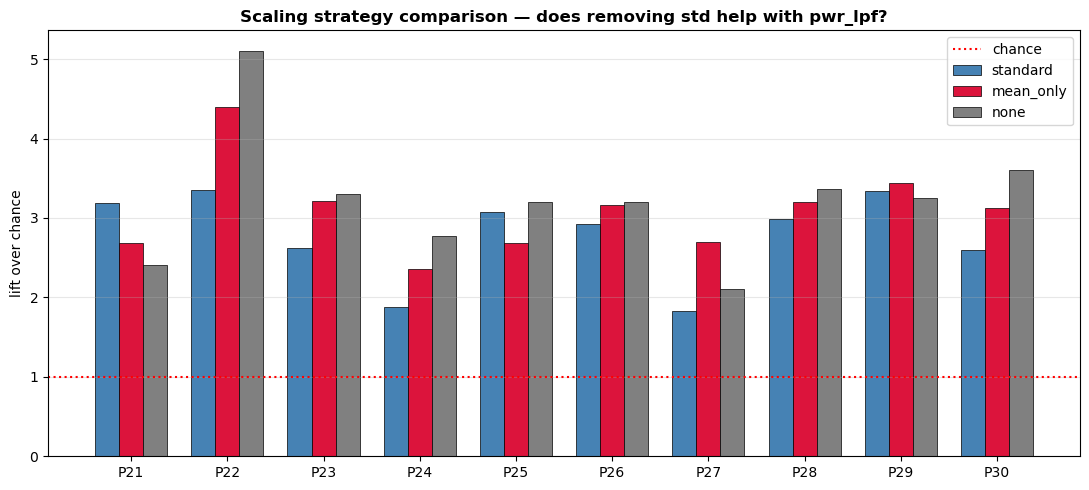


  Saved results to std_normalization_results_20260429_2205.pkl


In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 6 — Bar chart per patient + save
# ═══════════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(pids))
width = 0.25
colors = {'standard': 'steelblue', 'mean_only': 'crimson', 'none': 'gray'}

for k, v in enumerate(variants):
    lifts = [results[v].get(pid, {}).get('lift', 0) for pid in pids]
    offset = (k - 1) * width
    ax.bar(x + offset, lifts, width, color=colors[v],
           label=v, edgecolor='black', linewidth=0.5)

ax.axhline(1.0, color='red', ls=':', label='chance')
ax.set_xticks(x); ax.set_xticklabels(pids)
ax.set_ylabel('lift over chance')
ax.set_title('Scaling strategy comparison — does removing std help with pwr_lpf?',
             fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, axis='y')
ax.legend()
plt.tight_layout(); plt.show()

# Save raw results for later inspection (also used by the edit-distance cell)
out_path = f'std_normalization_results_{datetime.now().strftime("%Y%m%d_%H%M")}.pkl'
with open(out_path, 'wb') as f:
    pickle.dump(results, f)
print(f"\n  Saved results to {out_path}")


In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 7 — Edit distance between true and predicted phoneme sequences
# ═══════════════════════════════════════════════════════════════════════════════
# A pure-Python Levenshtein implementation, no extra packages needed.
# Edit distance counts the minimum (insertion + deletion + substitution)
# operations to transform one sequence into another.
#
# Phoneme Error Rate (PER) = edit_distance / len(true_sequence)
#   PER = 0 means perfect match
#   PER = 1 means worst case (every phoneme wrong)
#   PER > 1 is possible if predicted sequence has many extra insertions

def edit_distance(s1, s2):
    """Levenshtein edit distance between two sequences."""
    if len(s1) < len(s2):
        return edit_distance(s2, s1)
    if len(s2) == 0:
        return len(s1)

    previous_row = list(range(len(s2) + 1))
    for i, c1 in enumerate(s1):
        current_row = [i + 1]
        for j, c2 in enumerate(s2):
            insertions    = previous_row[j + 1] + 1
            deletions     = current_row[j] + 1
            substitutions = previous_row[j] + (c1 != c2)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row
    return previous_row[-1]


# Compute edit distance and PER for each patient under each scaling variant
print("\n" + "="*78)
print("  Edit distance between predicted and true phoneme sequences")
print("="*78)
header = f"  {'pid':<6} " + "".join(f"{v:>22}" for v in variants)
print(header)
sub  = f"  {'':<6} " + "".join(f"{'edit (PER)':>22}" for _ in variants)
print(sub)
print("  " + "-" * (len(header)-2))

for pid in pids:
    line = f"  {pid:<6} "
    for v in variants:
        if pid not in results[v]:
            line += f"{'—':>22}"
            continue
        true = results[v][pid]['true_labels']
        pred = results[v][pid]['predictions']
        ed = edit_distance(true, pred)
        per = ed / len(true) if true else float('nan')
        line += f"   {ed:>4} ({per:.2%})    "
    print(line)

# Aggregate stats
print("  " + "-" * (len(header)-2))
mean_line = f"  {'mean':<6} "
for v in variants:
    eds = []
    pers = []
    for pid in pids:
        if pid in results[v]:
            true = results[v][pid]['true_labels']
            pred = results[v][pid]['predictions']
            eds.append(edit_distance(true, pred))
            pers.append(edit_distance(true, pred) / len(true) if true else 0)
    mean_line += f"   {np.mean(eds):>4.0f} ({np.mean(pers):.2%})    "
print(mean_line)




  Edit distance between predicted and true phoneme sequences
  pid                  standard             mean_only                  none
                     edit (PER)            edit (PER)            edit (PER)
  -------------------------------------------------------------------------
  P21        822 (80.83%)        825 (81.12%)        828 (81.42%)    
  P22        716 (83.26%)        702 (81.63%)        702 (81.63%)    
  P23        626 (82.15%)        626 (82.15%)        631 (82.81%)    
  P24        411 (83.88%)        406 (82.86%)        409 (83.47%)    
  P25        681 (81.95%)        680 (81.83%)        675 (81.23%)    
  P26        605 (83.91%)        598 (82.94%)        589 (81.69%)    
  P27        489 (82.46%)        490 (82.63%)        484 (81.62%)    
  P28        746 (82.61%)        743 (82.28%)        735 (81.40%)    
  P29        951 (82.05%)        950 (81.97%)        958 (82.66%)    
  P30        595 (81.73%)        594 (81.59%)        596 (81.87%)    
  --------

  Per-patient feature std distribution (across all phonemes)
  pid     n_dim    min std   median std    max std   max/median
------------------------------------------------------------------------
  P21      4510      0.129        2.427     22.209         9.2×
  P22      4674      0.163        0.432      4.931        11.4× ←★
  P23      5330      0.187        0.432      4.157         9.6×
  P24      5330      0.230        0.547      8.099        14.8×
  P25      4838      0.120        0.444     26.264        59.2×
  P26      3690      0.090        0.361      4.742        13.1×
  P27      5330      0.040        0.496      2.386         4.8×
  P28      3690      0.032        0.445     16.235        36.5×
  P29      3444      0.107        0.392     11.821        30.2×
  P30      5330      0.045        0.486      3.110         6.4×


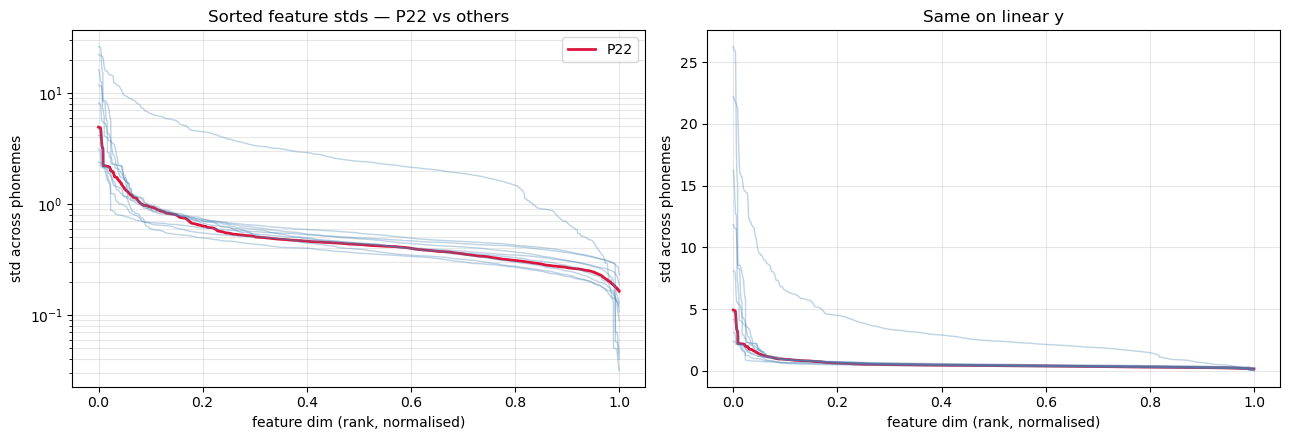


  P22 per-class accuracy across scaling variants
  class     support   standard  mean_only       none
------------------------------------------------------------
  aː             28        0%        4%       11%
  b              13        8%        8%        0%
  c               4        0%        0%        0%
  d              33       12%       15%       18%
  eː             64       12%       17%       14%
  f              15        0%        0%        7%
  h              21        0%        5%        0%
  i               1        0%        0%        0%
  iː             15        0%        0%        0%
  j              27       11%       15%       11%
  k              27        0%        4%        7%
  l              29        7%       10%       10%
  m              21       10%        0%        5%
  n              85       21%       22%       31%
  oː             16        6%        0%        0%
  p              26        0%        0%        0%
  r              46        4%       

AttributeError: 'Dutch30Pipeline' object has no attribute 'patient_results'

In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# Why is P22 unusual? Compare feature distributions across patients
# ═══════════════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

PID_OF_INTEREST = 'P22'

pids = sorted(set(pipeline.train['phoneme_participant_ids']))


# ── 1. Per-channel feature std distribution per patient ────────────────────
print("="*72)
print(f"  Per-patient feature std distribution (across all phonemes)")
print("="*72)
print(f"  {'pid':<6} {'n_dim':>6} {'min std':>10} {'median std':>12} "
      f"{'max std':>10} {'max/median':>12}")
print("-"*72)

per_patient_std_stats = {}
for pid in pids:
    idx = [i for i, p in enumerate(pipeline.train['phoneme_participant_ids']) if p == pid]
    X = np.array([pipeline.train['features'][i] for i in idx])
    stds = X.std(axis=0)   # std along axis 0 → one value per feature dim
    per_patient_std_stats[pid] = stds
    star = ' ←★' if pid == PID_OF_INTEREST else ''
    print(f"  {pid:<6} {X.shape[1]:>6} {stds.min():>10.3f} "
          f"{np.median(stds):>12.3f} {stds.max():>10.3f} "
          f"{stds.max()/max(np.median(stds), 1e-9):>11.1f}×{star}")


# ── 2. Visualise std distribution: sorted std per dim, all patients overlaid
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
for pid in pids:
    stds = np.sort(per_patient_std_stats[pid])[::-1]
    color = 'crimson' if pid == PID_OF_INTEREST else 'steelblue'
    alpha = 1.0 if pid == PID_OF_INTEREST else 0.35
    lw = 2.0 if pid == PID_OF_INTEREST else 1.0
    ax.plot(np.arange(len(stds)) / len(stds), stds, color=color,
            alpha=alpha, lw=lw, label=pid if pid == PID_OF_INTEREST else None)
ax.set_xlabel('feature dim (rank, normalised)')
ax.set_ylabel('std across phonemes')
ax.set_title(f'Sorted feature stds — {PID_OF_INTEREST} vs others')
ax.set_yscale('log'); ax.grid(alpha=0.3, which='both'); ax.legend()

# Same on linear y to see absolute spread
ax = axes[1]
for pid in pids:
    stds = np.sort(per_patient_std_stats[pid])[::-1]
    color = 'crimson' if pid == PID_OF_INTEREST else 'steelblue'
    alpha = 1.0 if pid == PID_OF_INTEREST else 0.35
    lw = 2.0 if pid == PID_OF_INTEREST else 1.0
    ax.plot(np.arange(len(stds)) / len(stds), stds, color=color,
            alpha=alpha, lw=lw)
ax.set_xlabel('feature dim (rank, normalised)')
ax.set_ylabel('std across phonemes')
ax.set_title('Same on linear y')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


# ── 3. Per-class accuracy: which phonemes does P22 do well/badly on?
def per_class_accuracy(true, pred):
    """Return {class: (accuracy, support)} dict."""
    classes = sorted(set(true))
    out = {}
    for c in classes:
        mask = [t == c for t in true]
        if not any(mask):
            continue
        n = sum(mask)
        correct = sum(p == t for p, t, m in zip(pred, true, mask) if m)
        out[c] = (correct / n, n)
    return out

# Need the predictions/labels from your three scaling variants
# Assumes you saved 'results' dict from std_normalization_test.py
print("\n"+"="*72)
print(f"  {PID_OF_INTEREST} per-class accuracy across scaling variants")
print("="*72)

if 'results' in dir():    # if std test results are still in scope
    if PID_OF_INTEREST in results['standard']:
        true_p22 = results['standard'][PID_OF_INTEREST]['true_labels']
        all_classes = sorted(set(true_p22))
        print(f"  {'class':<8} {'support':>8} {'standard':>10} "
              f"{'mean_only':>10} {'none':>10}")
        print("-"*60)
        for cls in all_classes:
            row = f"  {cls:<8}"
            n = sum(t == cls for t in true_p22)
            row += f" {n:>8}"
            for variant in ['standard', 'mean_only', 'none']:
                pca = per_class_accuracy(
                    results[variant][PID_OF_INTEREST]['true_labels'],
                    results[variant][PID_OF_INTEREST]['predictions'])
                acc = pca.get(cls, (0, 0))[0]
                row += f" {acc:>9.0%}"
            print(row)


# ── 4. Class distribution: is P22 unusually skewed?
print(f"\n  {PID_OF_INTEREST} class distribution:")
true_p22 = pipeline.patient_results[PID_OF_INTEREST]['true_labels']
counts = Counter(true_p22)
total = len(true_p22)
print(f"  {'class':<8} {'count':>6} {'fraction':>10}")
for cls, n in counts.most_common():
    print(f"  {cls:<8} {n:>6} {n/total:>9.1%}")
print(f"  TOTAL    {total:>6}  ({len(counts)} unique classes)")

In [11]:
from collections import Counter
def confusion(true, pred, true_class):
    return Counter(p for t, p in zip(true, pred) if t == true_class).most_common()

print("What does the model predict when the truth is /z/?")
for variant in ['standard', 'mean_only', 'none']:
    r = results[variant]['P22']
    c = confusion(r['true_labels'], r['predictions'], 'z')
    print(f"  {variant:10}: {c[:5]}")

What does the model predict when the truth is /z/?
  standard  : [('n', 4), ('s', 3), ('t', 2), ('r', 2), ('v', 1)]
  mean_only : [('t', 4), ('n', 3), ('s', 3), ('eː', 2), ('v', 1)]
  none      : [('z', 4), ('s', 3), ('t', 3), ('v', 2), ('j', 2)]


In [12]:
from collections import Counter

VOICING_PAIRS = [
    ('z', 's'), ('v', 'f'), ('b', 'p'), ('d', 't'), ('ɣ', 'x'),
]

def confusion(true, pred, true_class):
    return Counter(p for t, p in zip(true, pred) if t == true_class).most_common(5)

for voiced, unvoiced in VOICING_PAIRS:
    print(f"\n  /{voiced}/ vs /{unvoiced}/  (voicing pair):")
    for variant in ['standard', 'mean_only', 'none']:
        r = results[variant]['P22']
        true = r['true_labels']
        pred = r['predictions']
        n_voiced = sum(t == voiced for t in true)
        if n_voiced == 0:
            continue
        # Top confusions for the voiced phoneme
        conf = confusion(true, pred, voiced)
        # Cross-confusion: how often is voiced predicted as unvoiced?
        as_unvoiced = sum(1 for t, p in zip(true, pred) if t == voiced and p == unvoiced)
        as_correct = sum(1 for t, p in zip(true, pred) if t == voiced and p == voiced)
        print(f"    {variant:10}: support={n_voiced:>3}  "
              f"correct={as_correct:>3}  predicted-as-unvoiced={as_unvoiced:>3}  "
              f"top-5: {conf}")


  /z/ vs /s/  (voicing pair):
    standard  : support= 22  correct=  0  predicted-as-unvoiced=  3  top-5: [('n', 4), ('s', 3), ('t', 2), ('r', 2), ('v', 1)]
    mean_only : support= 22  correct=  0  predicted-as-unvoiced=  3  top-5: [('t', 4), ('n', 3), ('s', 3), ('eː', 2), ('v', 1)]
    none      : support= 22  correct=  4  predicted-as-unvoiced=  3  top-5: [('z', 4), ('s', 3), ('t', 3), ('v', 2), ('j', 2)]

  /v/ vs /f/  (voicing pair):
    standard  : support= 16  correct=  1  predicted-as-unvoiced=  0  top-5: [('eː', 3), ('aː', 2), ('x', 2), ('p', 2), ('t', 2)]
    mean_only : support= 16  correct=  0  predicted-as-unvoiced=  0  top-5: [('eː', 3), ('m', 2), ('p', 2), ('t', 2), ('s', 1)]
    none      : support= 16  correct=  0  predicted-as-unvoiced=  0  top-5: [('d', 2), ('s', 2), ('h', 2), ('t', 2), ('k', 1)]

  /b/ vs /p/  (voicing pair):
    standard  : support= 13  correct=  1  predicted-as-unvoiced=  0  top-5: [('ɛ', 2), ('ɪ', 2), ('h', 2), ('eː', 2), ('s', 1)]
    mean_only